In [21]:
import warnings
warnings.filterwarnings("ignore")

In [1]:
import pandas as pd

In [13]:
import pandas as pd

data = {
    'Player': [
        'Lamine Yamal', 'Erling Haaland', 'Kylian Mbappé', 'Jude Bellingham', 
        'Vinícius Júnior', 'Jamal Musiala', 'Bukayo Saka', 'Cole Palmer', 
        'Florian Wirtz', 'João Neves', 'William Saliba', 'Arda Güler', 
        'Alexander Isak', 'Harry Kane', 'Mohamed Salah', 'Kevin De Bruyne', 
        'Cristiano Ronaldo', 'Lionel Messi', 'Désiré Doué', 'Julián Álvarez'
    ],
    'Age': [18, 25, 27, 22, 25, 22, 24, 23, 22, 21, 24, 20, 26, 32, 33, 34, 41, 38, 20, 26],
    'Salary_MEuro': [15.0, 32.5, 33.5, 20.0, 25.0, 12.0, 15.0, 11.0, 10.0, 8.0, 
                     11.5, 6.0, 13.0, 26.5, 21.0, 24.0, 200.0, 50.0, 5.5, 12.5],
    'Transfer_Value_MEuro': [200.0, 200.0, 200.0, 160.0, 150.0, 130.0, 130.0, 120.0, 
                             110.0, 110.0, 90.0, 90.0, 120.0, 80.0, 55.0, 45.0, 
                             15.0, 25.0, 90.0, 100.0]
}

df = pd.DataFrame(data)
df

,Player,Age,Salary_MEuro,Transfer_Value_MEuro
0,Lamine Yamal,18,15.0,200.0
1,Erling Haaland,25,32.5,200.0
2,Kylian Mbappé,27,33.5,200.0
3,Jude Bellingham,22,20.0,160.0
4,Vinícius Júnior,25,25.0,150.0
5,Jamal Musiala,22,12.0,130.0
6,Bukayo Saka,24,15.0,130.0
7,Cole Palmer,23,11.0,120.0
8,Florian Wirtz,22,10.0,110.0
9,João Neves,21,8.0,110.0


In [14]:
features = df.drop(columns="Player")
features.head()

,Age,Salary_MEuro,Transfer_Value_MEuro
0,18,15.0,200.0
1,25,32.5,200.0
2,27,33.5,200.0
3,22,20.0,160.0
4,25,25.0,150.0


In [12]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [22]:
inertia = []
k_range = range(1, 10)

for k in k_range:
    model = KMeans(n_clusters=k)
    model.fit(features)
    inertia.append(model.inertia_)

In [23]:
inertia

[89416.85,
 48197.60526315789,
 21087.579545454544,
 7761.801136363636,
 3951.6904761904766,
 3017.357142857143,
 1416.0666666666666,
 1090.5666666666668,
 624.3333333333334]

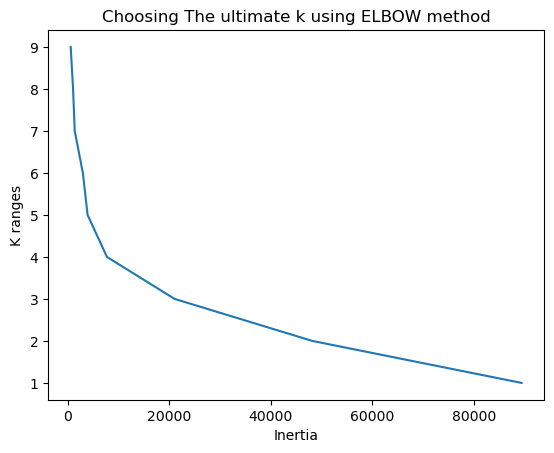

In [27]:
plt.plot(inertia, k_range)
plt.xlabel("Inertia")
plt.ylabel("K ranges")
plt.title("Choosing The ultimate k using ELBOW method")
plt.show()

In [28]:
model = KMeans(n_clusters=3)

In [29]:
model.fit(features)

KMeans(n_clusters=3)

In [30]:
model.cluster_centers_

array([[ 23.        ,  15.36666667, 133.33333333],
       [ 41.        , 200.        ,  15.        ],
       [ 34.25      ,  30.375     ,  51.25      ]])

In [33]:
model.cluster_centers_[:,2]

array([133.33333333,  15.        ,  51.25      ])

In [34]:
model.labels_

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 1, 2, 0, 0],
      dtype=int32)

In [35]:
df["Cluster_label"] = model.labels_

In [36]:
df.head()

,Player,Age,Salary_MEuro,Transfer_Value_MEuro,Cluster_label
0,Lamine Yamal,18,15.0,200.0,0
1,Erling Haaland,25,32.5,200.0,0
2,Kylian Mbappé,27,33.5,200.0,0
3,Jude Bellingham,22,20.0,160.0,0
4,Vinícius Júnior,25,25.0,150.0,0


In [60]:
def cluster_fn(col):
    if col == 0:
        return "cluster 0"
    elif col == 1:
        return "cluster 1"
    else:
        return "cluster 2"

In [61]:
df["Cluster_Name"] = df["Cluster_label"].apply(lambda x: cluster_fn(x))

In [62]:
df.head()

,Player,Age,Salary_MEuro,Transfer_Value_MEuro,Cluster_label,Cluster_Name
0,Lamine Yamal,18,15.0,200.0,0,cluster 0
1,Erling Haaland,25,32.5,200.0,0,cluster 0
2,Kylian Mbappé,27,33.5,200.0,0,cluster 0
3,Jude Bellingham,22,20.0,160.0,0,cluster 0
4,Vinícius Júnior,25,25.0,150.0,0,cluster 0


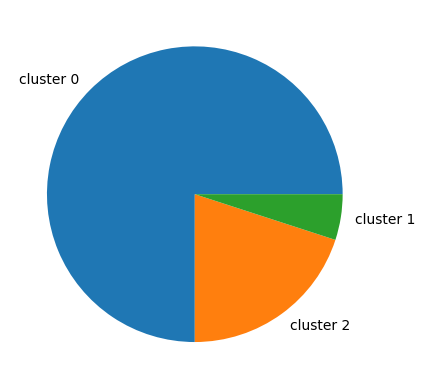

In [68]:
distinct_clusters = df["Cluster_label"].value_counts()
unique_clusters = df["Cluster_Name"].unique()
plt.pie(distinct_clusters.values, labels=unique_clusters)
plt.show()

In [76]:
df[df["Cluster_label"] == 1]

,Player,Age,Salary_MEuro,Transfer_Value_MEuro,Cluster_label,Cluster_Name
16,Cristiano Ronaldo,41,200.0,15.0,1,cluster 1


In [77]:
df[df["Cluster_label"] == 2]

,Player,Age,Salary_MEuro,Transfer_Value_MEuro,Cluster_label,Cluster_Name
13,Harry Kane,32,26.5,80.0,2,cluster 2
14,Mohamed Salah,33,21.0,55.0,2,cluster 2
15,Kevin De Bruyne,34,24.0,45.0,2,cluster 2
17,Lionel Messi,38,50.0,25.0,2,cluster 2
